# Environment

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from glob import glob
os.chdir('/Users/burkelawlor/Repos/hci-Xenium')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import spatialdata as sd
import scanpy as sc
import squidpy as sq
import anndata as ad
from spatialdata_io import xenium
import gseapy as gp

from itertools import combinations

from utils.data_loading import sample_sets
from utils.diffex import *

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Load data

In [4]:
adata_lp = ad.read_h5ad("./data/processed/adata/lp+yale_2_annotated.h5ad")

adata_immune = adata_lp[adata_lp.obs['ct_immune'].notna()].copy()

immune_cts = adata_immune.obs['ct_immune'].unique().to_list()
immune_cts.sort()

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [5]:
adata_lp.obs.groupby('sample_set')['sample_name'].nunique()

sample_set
ICI_LP    4
LP        7
LPP       4
NL        4
OLP       6
Name: sample_name, dtype: int64

In [6]:
combos = [
    ('LP',     'NL'),
    ('ICI_LP', 'NL'),
    ('LPP',    'NL'),
    ('OLP',    'NL'),
    ('ICI_LP', 'LP' ),
    ('LPP',    'LP' ),
    ('OLP',    'LP' ),
]

In [15]:
genes_of_interest = ['KLRD1','CXCL13','GZMK','CD8A','CD8B','IFNG','FCGR3A','TNFSF9','NCAM1','LAMP3','IL15','IL12B','LAIR1']

# Bulk

In [ ]:
adata = adata_lp.copy()

sample_col = 'sample_name'
celltype_col = None
condition = 'sample_set'


analyses_dict = {}
all_diffex_results = []
all_sig_by_gene_results = []
all_sig_by_ct_results = []

for comparison in combos:
    print(comparison)
    
    # Run differential expression analysis
    contrast = (condition, comparison[0], comparison[1])
    adata_subset = adata[adata.obs[condition].isin(comparison)].copy()
    analysis = DiffExAnalysis(adata_subset, sample_col=sample_col, celltype_col=celltype_col, condition_col=condition, contrast=contrast)
    results_df = analysis.run()
    analyses_dict[comparison] = analysis

    # Save results
    results_df['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_diffex_results.append(results_df)

    # Summarize results by gene
    sig_by_gene = analysis.summarize_sig_by_gene()
    sig_by_gene_immune = analysis.summarize_sig_by_gene(subset_cts=immune_cts)
    sig_by_gene = pd.merge(sig_by_gene, sig_by_gene_immune, left_index=True, right_index=True, suffixes=('','_immune')).reset_index()
    sig_by_gene['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_gene_results.append(sig_by_gene)

    # Summarize results by cell type
    sig_by_ct = results_df.groupby('ct').agg({'sig': 'sum'}).sort_values('sig', ascending=False).reset_index()
    sig_by_ct['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_ct_results.append(sig_by_ct)


    # GSEA 
    gsea_results_df = run_gsea(results_df, outdir=f"output/lp-analysis/gsea_prerank_output/bulk/{'-'.join(comparison)}")


# Concatenate results
all_diffex_results_df = pd.concat(all_diffex_results, ignore_index=True)
all_sig_by_gene_df = pd.concat(all_sig_by_gene_results, ignore_index=True)
all_sig_by_ct_df = pd.concat(all_sig_by_ct_results, ignore_index=True)
all_sig_by_ct_df = all_sig_by_ct_df.pivot(columns='comparison', index='ct', values='sig')


# Write out
prefix = 'bulk'
all_diffex_results_df.to_csv(f'./output/lp-analysis/diffex/{prefix}_diffex_results.csv', index=False)
all_sig_by_gene_df.to_csv(f'./output/lp-analysis/{prefix}_summary_by_gene.csv', index=False)
all_sig_by_ct_df.to_csv(f'./output/lp-analysis/{prefix}_summary_by_ct.csv')


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


('LP', 'NL')


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 91 outlier genes.

Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.02 seconds.

Running Wald tests...
... done in 0.14 seconds.

2026-06-25 12:12:53,631 [INFO] Parsing data files for GSEA.............................
2026-06-25 12:12:53,633 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-06-25 12:12:53,638 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-06-25 12:12:53,638 [INFO] 0050 gene_sets used for further statistical testing.....
2026-06-25 12:12:53,639 [INFO] Start to run GSEA..

...

Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.23 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 98 outlier genes.

Fitting dispersions...
... done in 0.03 seconds.

Fitting MAP dispersions...
... done in 0.02 seconds.

Fitting LFCs...
... done in 0.03 seconds.

Running Wald tests...
... done in 0.14 seconds.

2026-06-25 12:13:34,528 [INFO] Parsing data files for GSEA.............................
2026-06-25 12:13:34,530 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-06-25 12:13:34,533 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-06-25 12:13:34,533 [INFO] 0050 gene_sets used for further statistical testing.....
2026-06-25 12:13:34,534 [INFO] Start to run GSEA...Might take a while..................


Log2 fold change & Wald test p-value: sample_set OLP vs LP
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1    9441.690673        2.170871  0.535546  4.053567  0.000050  0.001155
AAMP     1578.179806       -0.346944  0.130357 -2.661500  0.007779  0.044381
AAR2      428.410093       -0.117936  0.106060 -1.111973  0.266150  0.449982
AARSD1    380.606695        0.417783  0.146420  2.853313  0.004327  0.030068
ABAT      155.571638        0.533299  0.275489  1.935828  0.052889  0.156152
...              ...             ...       ...       ...       ...       ...
ZSCAN26   298.453855        0.395709  0.258762  1.529241  0.126205  0.273489
ZSWIM6    291.634719       -0.007792  0.172424 -0.045189  0.963957  0.981738
ZUP1      525.407505        0.051854  0.102729  0.504761  0.613727  0.762402
ZYG11B    584.332391       -0.695249  0.203310 -3.419655  0.000627  0.007296
ZYX      2869.410507        0.830182  0.361566  2.296071  0.021672  0.085263

[5001 rows x 6 c

2026-06-25 12:13:36,534 [INFO] Congratulations. GSEApy runs successfully................



       Name                             Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
1   prerank              Allograft Rejection  0.490976  1.811241   0.001000   0.040089       0.038  64/131  23.55%  IL1B;CD1D;CD79A;KLRD1;ITGAL;CD7;CD8A;CCR5;CD24...
3   prerank                   Myc Targets V1  0.497893  1.695091   0.002933   0.054267       0.100   38/79  24.67%  CCT2;NOLC1;CCT7;PTGES3;CCT5;XPO1;COPS5;HSPD1;K...
2   prerank             IL-2/STAT5 Signaling  0.474202  1.726592   0.003125   0.056711       0.080  41/122  19.00%  EMP1;EOMES;SELP;ITGAE;TNFRSF21;SELL;TLR7;RHOH;...
7   prerank  Reactive Oxygen Species Pathway  0.633494  1.593259   0.021687   0.062334       0.221    8/18  14.11%          NQO1;OXSR1;SOD1;GSR;ABCC1;PTPA;SCAF4;G6PD
4   prerank            Inflammatory Response  0.439768  1.645239   0.001000   0.062969       0.145  57/138  22.94%  IL1B;BDKRB1;SELE;HBEGF;SELL;CALCRL;IL1A;PVR;OL...
6   

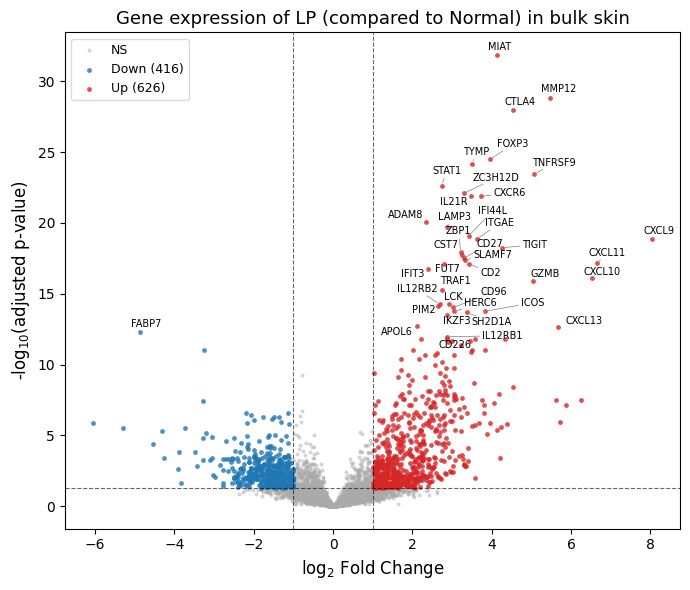

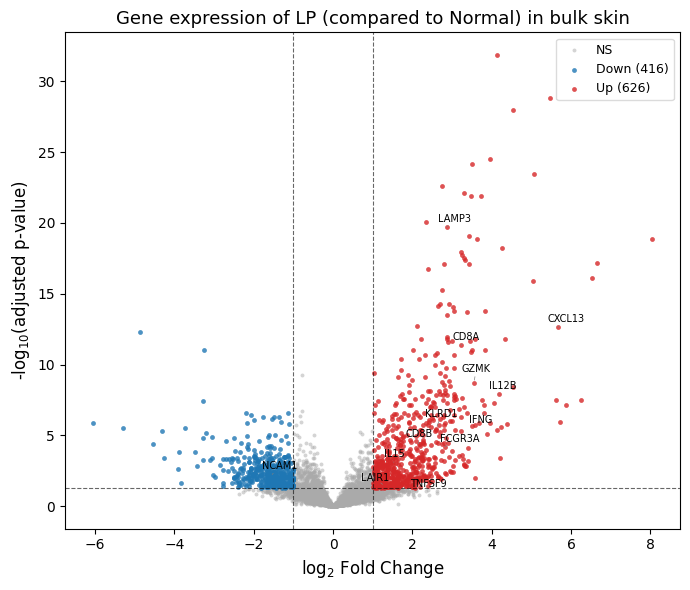

In [16]:
all_diffex_results_df = pd.read_csv('./output/lp-analysis/diffex/bulk_diffex_results.csv')

comparison = 'LP vs NL'

df = all_diffex_results_df[all_diffex_results_df['comparison'] == comparison]

plot_volcano(df, f'Gene expression of LP (compared to Normal) in bulk skin', top_n_labels=40)
plt.show()

plot_volcano(df, f'Gene expression of LP (compared to Normal) in bulk skin', top_n_labels=0, labels=genes_of_interest)
plt.show()

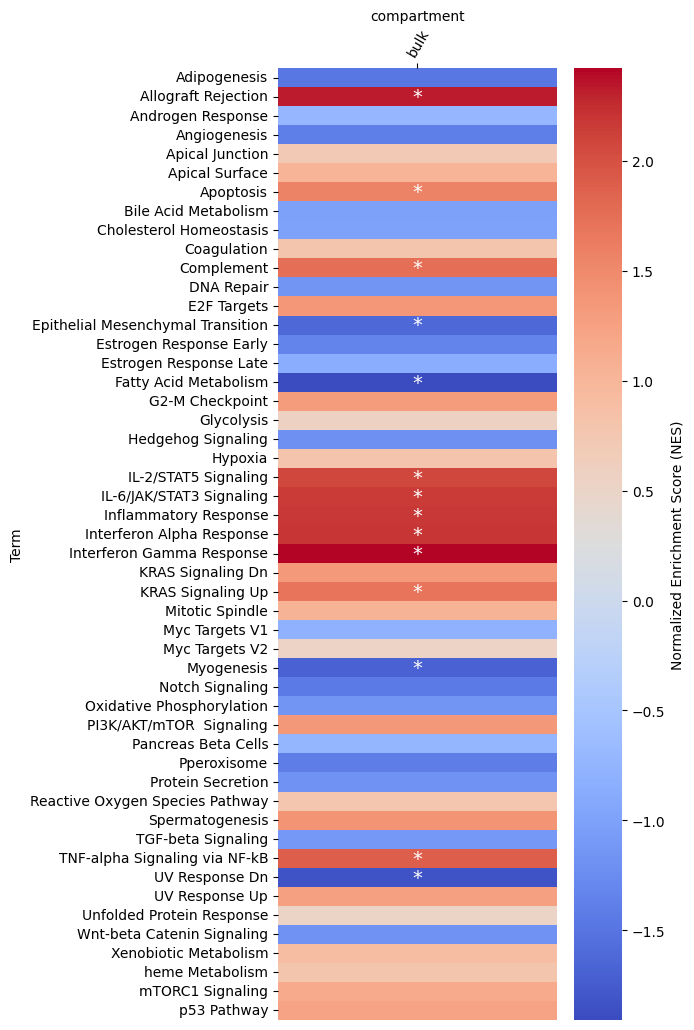

In [4]:
f = './output/lp-analysis/gsea_prerank_output/bulk/LP-NL/gseapy.gene_set.prerank.report.csv'

gsea_result = pd.read_csv(f)
gsea_result['compartment'] = 'bulk'
plot_gsea_heatmap(gsea_result, 'compartment')

# Immune

In [ ]:
adata = adata_immune.copy()

sample_col = 'sample_name'
celltype_col = None
condition = 'sample_set'


analyses_dict = {}
all_diffex_results = []
all_sig_by_gene_results = []
all_sig_by_ct_results = []

for comparison in combos:
    print(comparison)
    
    # Run differential expression analysis
    contrast = (condition, comparison[0], comparison[1])
    adata_subset = adata[adata.obs[condition].isin(comparison)].copy()
    analysis = DiffExAnalysis(adata_subset, sample_col=sample_col, celltype_col=celltype_col, condition_col=condition, contrast=contrast)
    results_df = analysis.run()
    analyses_dict[comparison] = analysis

    # Save results
    results_df['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_diffex_results.append(results_df)

    # Summarize results by gene
    sig_by_gene = analysis.summarize_sig_by_gene()
    sig_by_gene_immune = analysis.summarize_sig_by_gene(subset_cts=immune_cts)
    sig_by_gene = pd.merge(sig_by_gene, sig_by_gene_immune, left_index=True, right_index=True, suffixes=('','_immune')).reset_index()
    sig_by_gene['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_gene_results.append(sig_by_gene)

    # Summarize results by cell type
    sig_by_ct = results_df.groupby('ct').agg({'sig': 'sum'}).sort_values('sig', ascending=False).reset_index()
    sig_by_ct['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_ct_results.append(sig_by_ct)


    # GSEA 
    gsea_results_df = run_gsea(results_df, outdir=f"output/lp-analysis/gsea_prerank_output/immune/{'-'.join(comparison)}")


# Concatenate results
all_diffex_results_df = pd.concat(all_diffex_results, ignore_index=True)
all_sig_by_gene_df = pd.concat(all_sig_by_gene_results, ignore_index=True)
all_sig_by_ct_df = pd.concat(all_sig_by_ct_results, ignore_index=True)
all_sig_by_ct_df = all_sig_by_ct_df.pivot(columns='comparison', index='ct', values='sig')


# Write out
prefix = 'immune'
all_diffex_results_df.to_csv(f'./output/lp-analysis/diffex/{prefix}_diffex_results.csv', index=False)
all_sig_by_gene_df.to_csv(f'./output/lp-analysis/{prefix}_summary_by_gene.csv', index=False)
all_sig_by_ct_df.to_csv(f'./output/lp-analysis/{prefix}_summary_by_ct.csv')

/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


('LP', 'NL')


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.30 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 2 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.14 seconds.

2026-06-25 12:13:40,054 [INFO] Parsing data files for GSEA.............................
2026-06-25 12:13:40,056 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-06-25 12:13:40,059 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-06-25 12:13:40,060 [INFO] 0050 gene_sets used for further statistical testing.....
2026-06-25 12:13:40,060 [INFO] Start to run GSEA...Might take a while..................


...

Using None as control genes, passed at DeseqDataSet initialization


... done in 0.30 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 25 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.14 seconds.

2026-06-25 12:14:06,815 [INFO] Parsing data files for GSEA.............................
2026-06-25 12:14:06,817 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-06-25 12:14:06,821 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-06-25 12:14:06,821 [INFO] 0050 gene_sets used for further statistical testing.....
2026-06-25 12:14:06,821 [INFO] Start to run GSEA...Might take a while..................


Log2 fold change & Wald test p-value: sample_set OLP vs LP
            baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
A2ML1      54.252441       -1.033818  0.912088 -1.133463  0.257020  0.471255
AAMP      352.116757       -0.243268  0.133164 -1.826833  0.067725  0.205230
AAR2      122.146269        0.239081  0.160624  1.488454  0.136631  0.317323
AARSD1     99.842291        0.343174  0.235575  1.456750  0.145185  0.331212
ABAT       81.967443        0.162177  0.197510  0.821106  0.411586  0.621134
...              ...             ...       ...       ...       ...       ...
ZSCAN26   126.250357        0.294764  0.214269  1.375673  0.168923  0.364270
ZSWIM6    101.546973       -0.338579  0.191343 -1.769486  0.076813  0.223428
ZUP1      171.952341       -0.102864  0.127680 -0.805636  0.420453  0.627329
ZYG11B    154.681961       -0.575525  0.179316 -3.209561  0.001329  0.015437
ZYX      1234.058541        0.301156  0.222355  1.354394  0.175611  0.372965

[5001 rows x 6 c

2026-06-25 12:14:08,021 [INFO] Congratulations. GSEApy runs successfully................



       Name                               Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
0   prerank                     Myc Targets V1  0.516155  1.852268   0.001000   0.007463       0.006   36/79  18.83%  CCT7;PTGES3;NOLC1;CCT2;CCT3;COPS5;XPO1;CCT5;SF...
1   prerank          Unfolded Protein Response  0.559608  1.652562   0.011792   0.054110       0.084   12/33  11.93%  EIF4G1;NOLC1;MTREX;EIF4A3;HYOU1;EIF4A1;YWHAZ;D...
3   prerank          Interferon Gamma Response  0.410866  1.473591   0.007895   0.194465       0.371   37/97  18.08%  IFNAR2;STAT3;KLRK1;GZMA;SAMHD1;SP110;FAS;SELP;...
7   prerank          Oxidative Phosphorylation  0.418473  1.352667   0.059783   0.239245       0.671   20/45  23.69%  OGDH;PDHA1;ATP5F1A;IMMT;CPT1A;VDAC1;PDHB;HSPA9...
8   prerank  Epithelial Mesenchymal Transition  0.368221  1.326997   0.048851   0.245228       0.732   27/97  18.61%  IGFBP2;FGF2;MEST;FAS;GREM1;THBS2;CDH6;LRRC

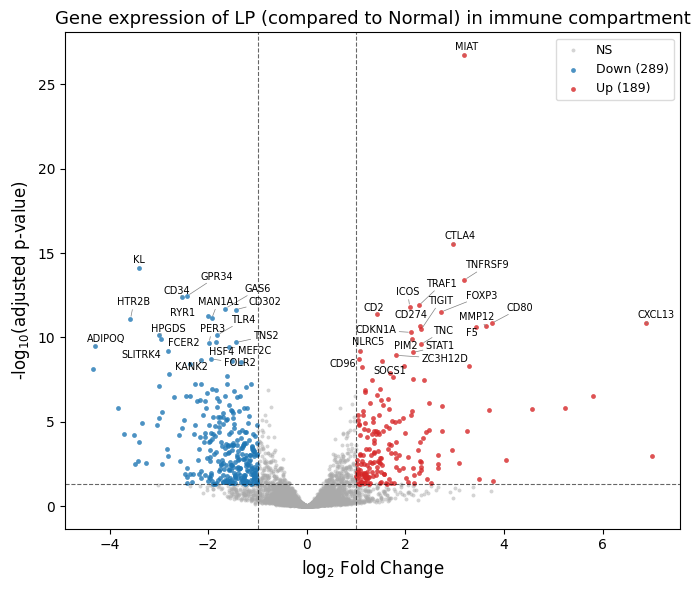

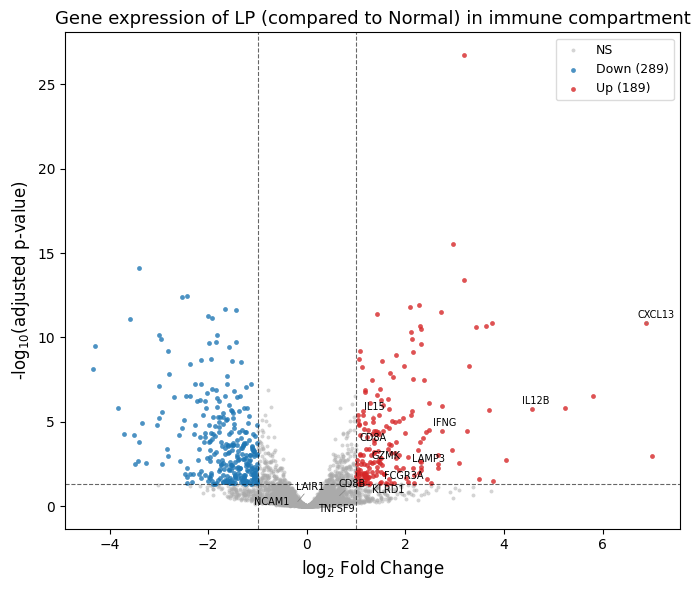

In [14]:
all_diffex_results_df = pd.read_csv('./output/lp-analysis/diffex/immune_diffex_results.csv')

comparison = 'LP vs NL'

df = all_diffex_results_df[all_diffex_results_df['comparison'] == comparison]
plot_volcano(df, f'Gene expression of LP (compared to Normal) in immune compartment', top_n_labels=40)
plt.show()

plot_volcano(df, f'Gene expression of LP (compared to Normal) in immune compartment', top_n_labels=0, labels=genes_of_interest)
plt.show()

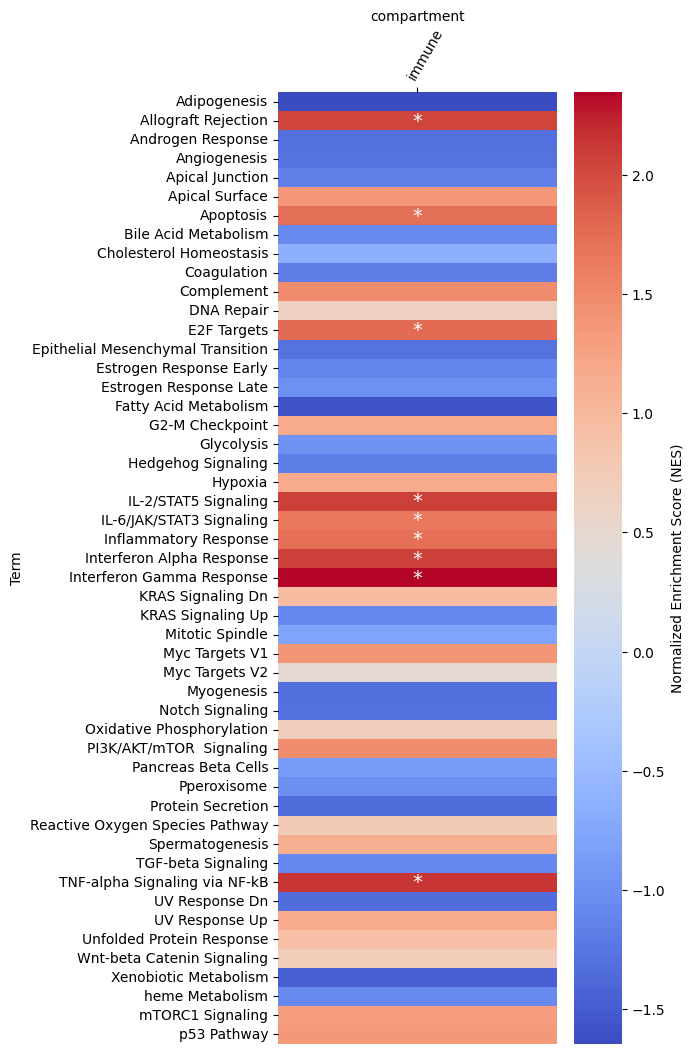

In [7]:
f = './output/lp-analysis/gsea_prerank_output/immune/LP-NL/gseapy.gene_set.prerank.report.csv'

gsea_result = pd.read_csv(f)
gsea_result['compartment'] = 'immune'
plot_gsea_heatmap(gsea_result, 'compartment')

# All cell types

In [66]:
adata = adata_lp.copy()

sample_col = 'sample_name'
celltype_col = 'ct_detailed'
condition = 'sample_set'


analyses_dict = {}
all_diffex_results = []
all_sig_by_gene_results = []
all_sig_by_ct_results = []

for comparison in combos:
    print(comparison)
    
    # Run differential expression analysis
    contrast = (condition, comparison[0], comparison[1])
    adata_subset = adata[adata.obs[condition].isin(comparison)].copy()
    analysis = DiffExAnalysis(adata_subset, sample_col=sample_col, celltype_col=celltype_col, condition_col=condition, contrast=contrast)
    results_df = analysis.run()
    analyses_dict[comparison] = analysis

    # Save results
    results_df['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_diffex_results.append(results_df)

    # Summarize results by gene
    sig_by_gene = analysis.summarize_sig_by_gene()
    sig_by_gene_immune = analysis.summarize_sig_by_gene(subset_cts=immune_cts)
    sig_by_gene = pd.merge(sig_by_gene, sig_by_gene_immune, left_index=True, right_index=True, suffixes=('','_immune')).reset_index()
    sig_by_gene['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_gene_results.append(sig_by_gene)

    # Summarize results by cell type
    sig_by_ct = results_df.groupby('ct').agg({'sig': 'sum'}).sort_values('sig', ascending=False).reset_index()
    sig_by_ct['comparison'] = f"{comparison[0]} vs {comparison[1]}"
    all_sig_by_ct_results.append(sig_by_ct)


    # GSEA -- we're writing these out here
    for ct in results_df.ct.unique():
        print(ct)
        ct_result = results_df[results_df.ct == ct].copy()
        gsea_results_df = run_gsea(ct_result, outdir=f"output/lp-analysis/gsea_prerank_output/{ct}/{'-'.join(comparison)}")


all_diffex_results_df = pd.concat(all_diffex_results, ignore_index=True)
all_diffex_results_df.to_csv('./output/lp-analysis/diffex/by_ct_diffex_results.csv', index=False)

all_sig_by_gene_df = pd.concat(all_sig_by_gene_results, ignore_index=True)
all_sig_by_gene_df.to_csv('./output/lp-analysis/diffex/by_ct_diffex_summary_by_gene.csv', index=False)

all_sig_by_ct_df = pd.concat(all_sig_by_ct_results, ignore_index=True)
all_sig_by_ct_df = all_sig_by_ct_df.pivot(columns='comparison', index='ct', values='sig')
all_sig_by_ct_df.to_csv('./output/lp-analysis/diffex/by_ct_diffex_summary_by_ct.csv')


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


('LP', 'NL')


/Users/burkelawlor/Repos/hci-xenium/.venv/lib/python3.12/site-packages/anndata/_core/anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


[SKIP] B cells: only 3 pseudobulk samples (need 4)
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.17 seconds.

Fitting dispersion trend curve...
... done in 0.04 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 15 outlier genes.

Fitting dispersions...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.01 seconds.

Fitting LFCs...
... done in 0.01 seconds.

Running Wald tests...
... done in 0.15 seconds.



...

       Name                               Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
2   prerank                       Angiogenesis -0.757955 -1.929237   0.001000   0.002480       0.006    6/20   3.93%              COL5A2;CCND2;POSTN;FSTL1;APP;SERPINA5
1   prerank  Epithelial Mesenchymal Transition -0.573121 -1.958462   0.001000   0.003306       0.004  29/100  10.14%  COL5A2;PDGFRB;COMP;HTRA1;COL4A1;COL4A2;LRP1;IT...
3   prerank                        Coagulation  -0.56761 -1.800886   0.001000   0.005786       0.020   22/64  15.00%  COMP;HTRA1;CTSK;LRP1;RAC1;ADAM9;PROS1;LGMN;DCT...
0   prerank                     Myc Targets V1  0.503716  2.038662   0.001000   0.008437       0.005   45/79  21.26%  CCT5;PCNA;CCT3;CCT2;PTGES3;SRSF1;SF3A1;MCM7;XR...
5   prerank                    Apical Junction -0.495352 -1.636371   0.001193   0.042981       0.189   31/99  20.76%  ADAMTS5;CD209;CD99;GNAI2;CD276;ADAM9;TRAF1

2026-06-25 15:29:39,040 [INFO] Congratulations. GSEApy runs successfully................

2026-06-25 15:29:39,048 [WARNING] Duplicated values found in preranked stats: 4.62% of genes
The order of those genes will be arbitrary, which may produce unexpected results.
2026-06-25 15:29:39,049 [INFO] Parsing data files for GSEA.............................
2026-06-25 15:29:39,051 [INFO] Enrichr library gene sets already downloaded in: /Users/burkelawlor/.cache/gseapy, use local file
2026-06-25 15:29:39,054 [INFO] 0000 gene_sets have been filtered out when max_size=500 and min_size=15
2026-06-25 15:29:39,054 [INFO] 0050 gene_sets used for further statistical testing.....
2026-06-25 15:29:39,054 [INFO] Start to run GSEA...Might take a while..................


       Name                           Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
0   prerank      Interferon Gamma Response  0.641128  2.329349   0.001000   0.001000       0.001  54/102  14.59%  STAT3;IDO1;CD38;PTGS2;PTPN2;SLAMF7;STAT1;NCOA3...
2   prerank          Inflammatory Response  0.471461  1.789232   0.001000   0.017528       0.033  36/140  14.63%  CYBB;SELL;CD14;IFNAR1;C5AR1;PTAFR;IL1B;CSF3R;H...
3   prerank                Spermatogenesis  -0.55745 -1.760178   0.001721   0.022472       0.042    8/53  10.14%       ALOX15;IL12RB2;HBZ;RFC4;NEFH;EZH2;HTR5A;PHF7
1   prerank                 Myc Targets V1  0.507707  1.794414   0.001000   0.024698       0.031   27/79  11.13%  HSPD1;EIF4A1;PTGES3;CCT2;CCT5;CDC20;PCNA;C1QBP...
6   prerank      Unfolded Protein Response  0.578631  1.693527   0.010989   0.024964       0.090   15/33  15.07%  EIF4G1;EIF4A1;YWHAZ;EIF4A3;DKC1;HSPA9;NOLC1;DC...
5   prerank     

2026-06-25 15:29:41,809 [INFO] Congratulations. GSEApy runs successfully................



       Name                           Term        ES       NES  NOM p-val  FDR q-val  FWER p-val   Tag %  Gene %                                         Lead_genes
0   prerank      Interferon Gamma Response  0.577205  2.064372   0.001000   0.001332       0.001  42/100  16.55%  ICAM1;SELP;PLA2G4A;PTGS2;SAMHD1;HERC6;CFH;VCAM...
1   prerank      Interferon Alpha Response  0.643701  1.920119   0.001000   0.003997       0.006   24/40  18.71%  HERC6;SELL;CSF1;ADAR;IFITM1;IFI35;OAS1;SAMD9;I...
2   prerank                 Myc Targets V1  0.496333  1.732571   0.002160   0.039529       0.084   32/79  15.98%  CCT2;CCT7;SF3B3;NOLC1;CCT5;SF3A1;XPO1;PTGES3;D...
3   prerank          Inflammatory Response  0.448319  1.687663   0.001000   0.043638       0.118  39/139  15.26%  CD14;ICAM1;HAS2;CALCRL;SELE;SELL;VIP;P2RY2;PTG...
4   prerank  TNF-alpha Signaling via NF-kB  0.451188  1.642148   0.002024   0.049833       0.166  31/108  13.53%  HES1;NR4A1;ICAM1;KLF4;PTGS2;ACKR3;TIPARP;PTGER...
6   prerank     

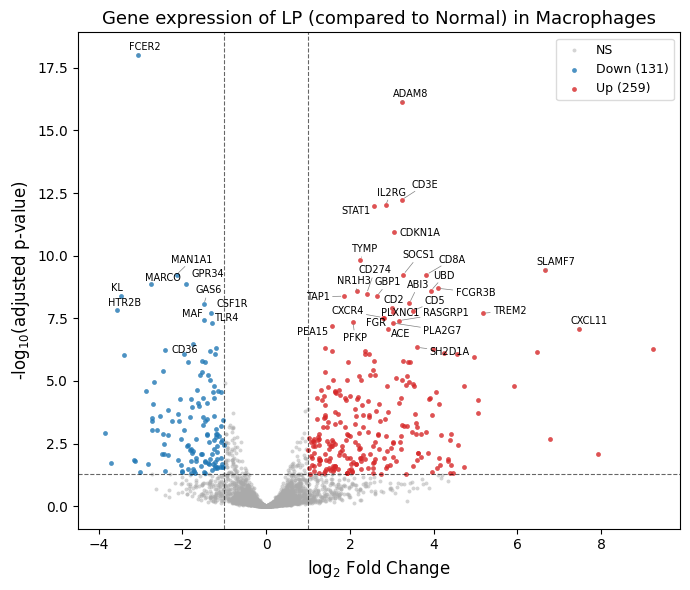

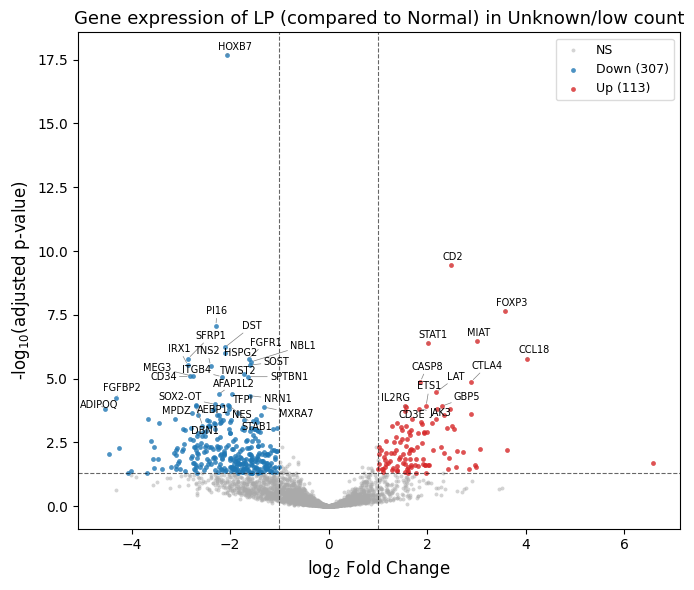

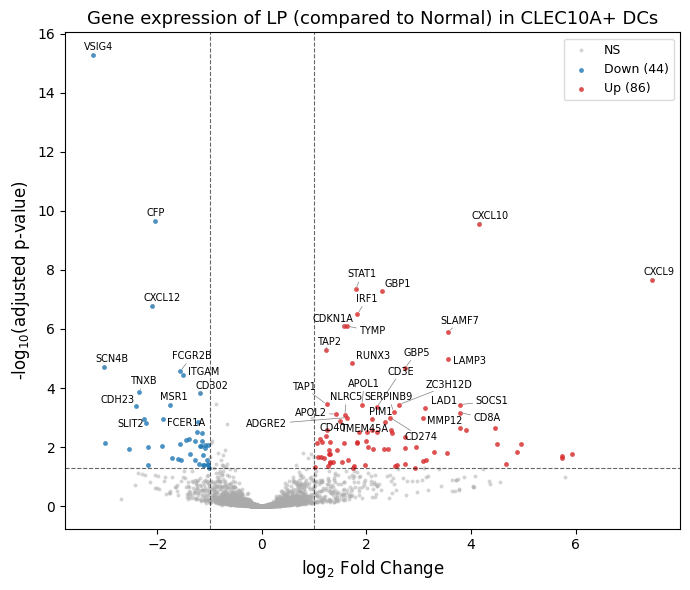

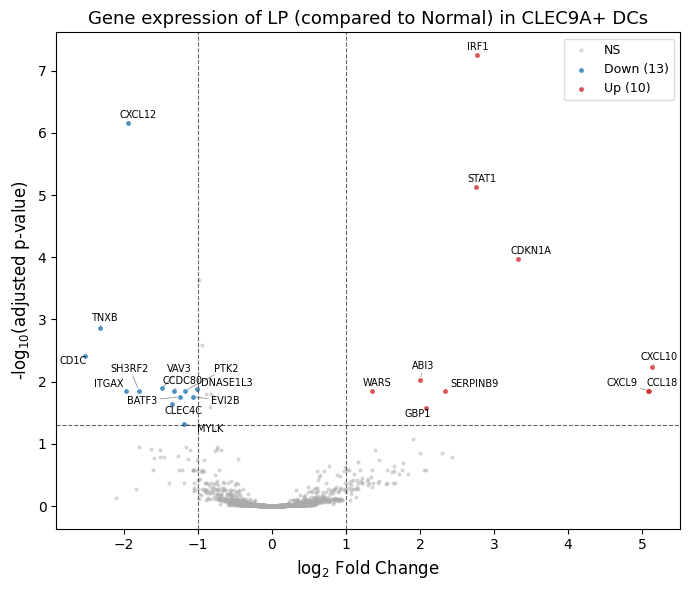

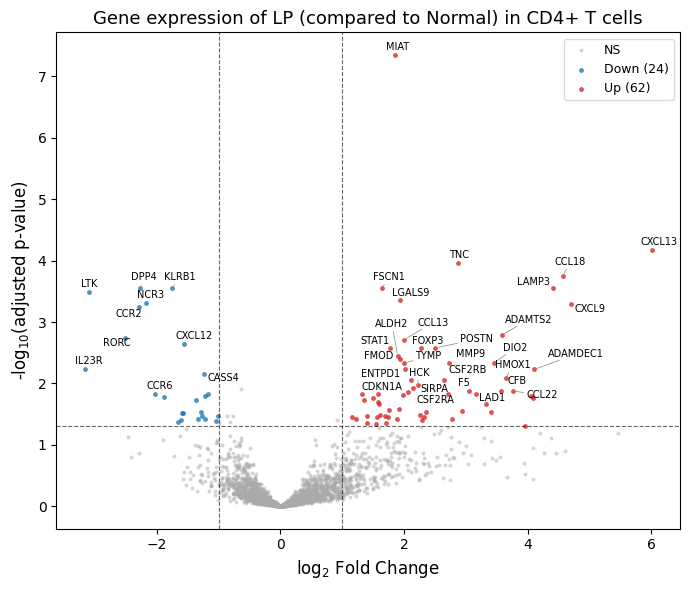

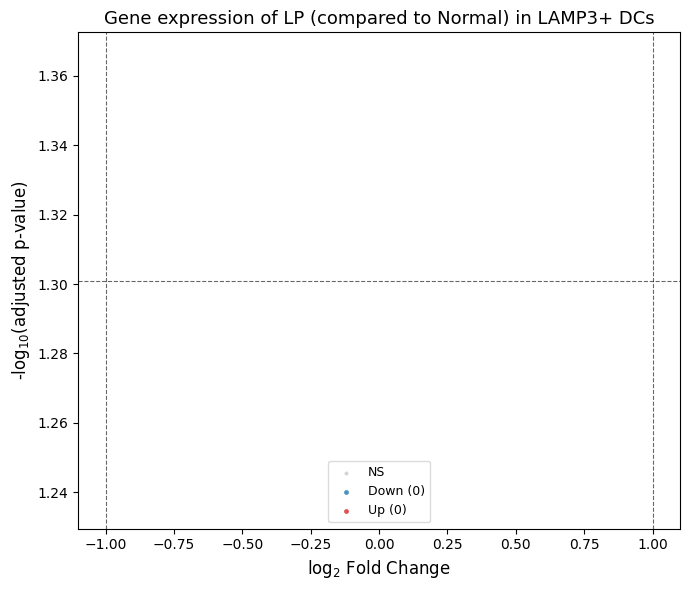

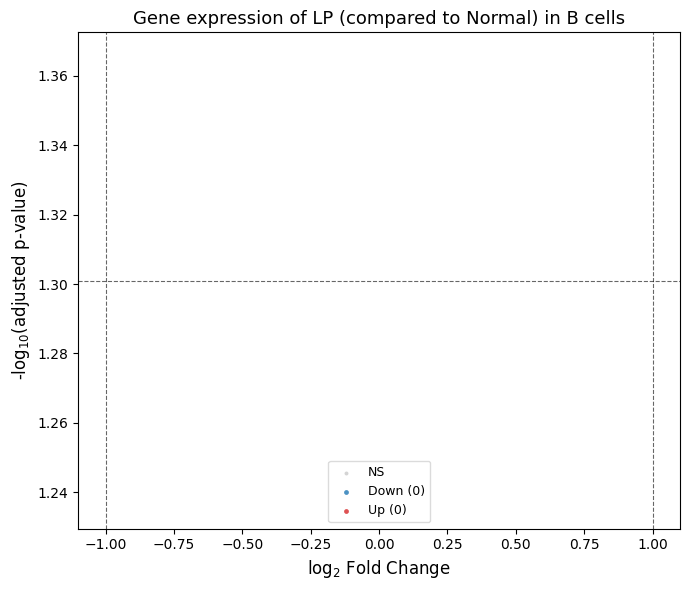

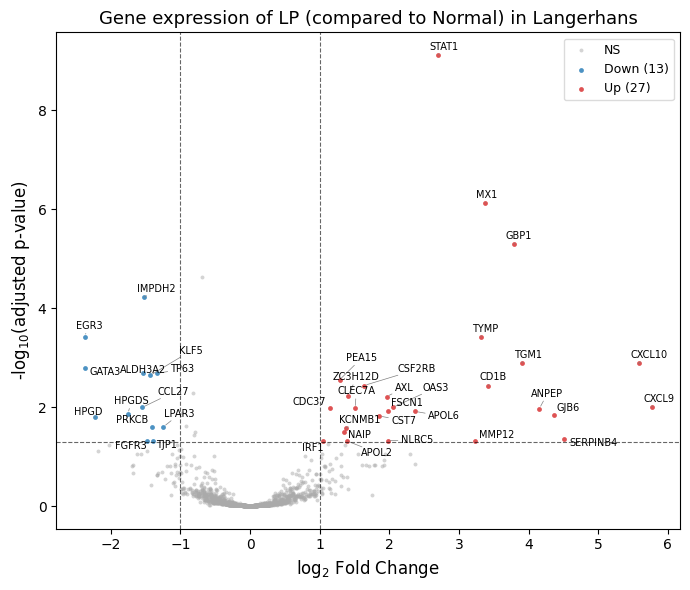

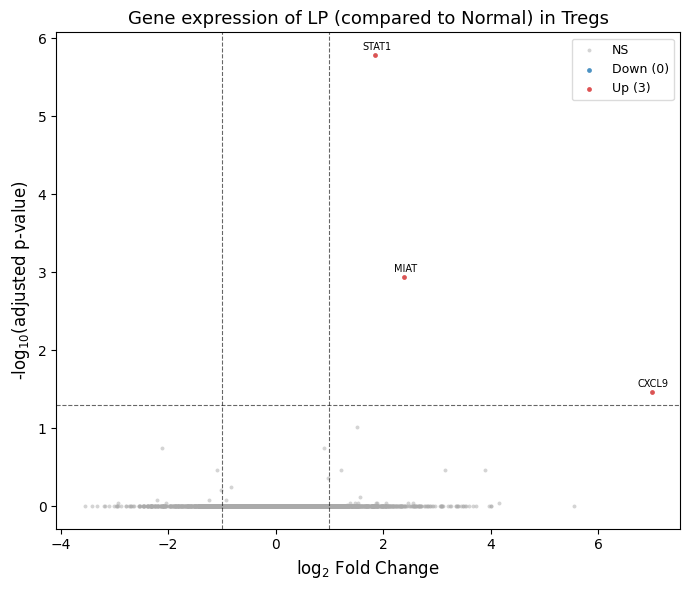

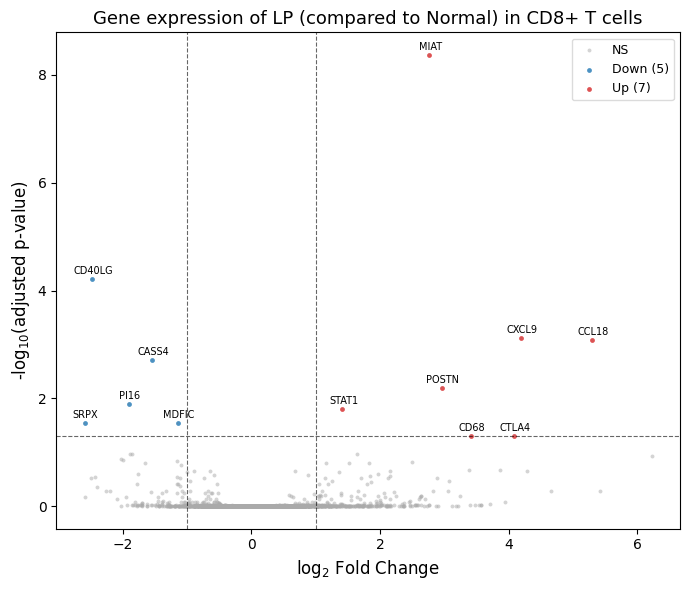

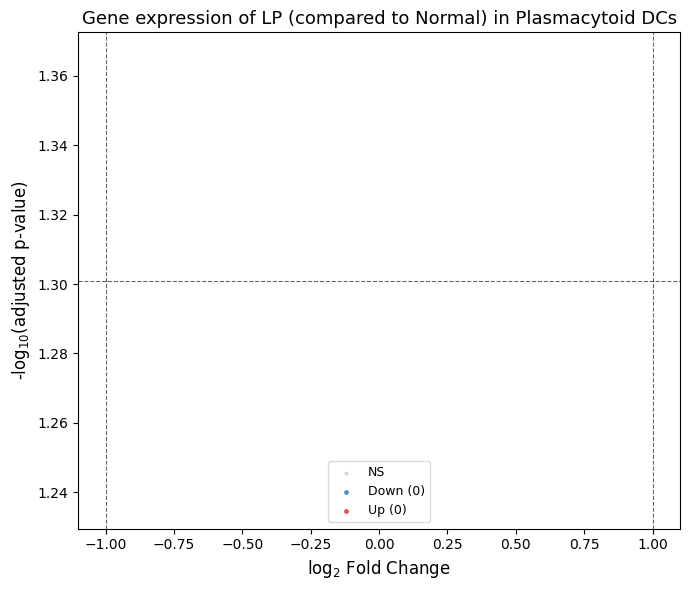

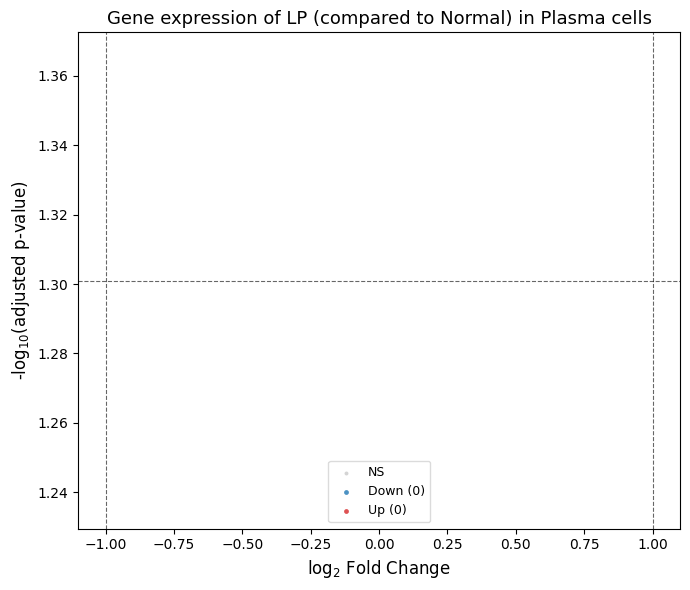

In [22]:
all_diffex_results_df = pd.read_csv('./output/lp-analysis/diffex/by_ct_diffex_results.csv')
all_diffex_results_df.ct.unique()


for ct in immune_cts:
    comparison = 'LP vs NL'

    df = all_diffex_results_df[(all_diffex_results_df['comparison'] == comparison) & (all_diffex_results_df['ct'] == ct)]
    plot_volcano(df, f'Gene expression of LP (compared to Normal) in {ct}', top_n_labels=40)
    plt.show()

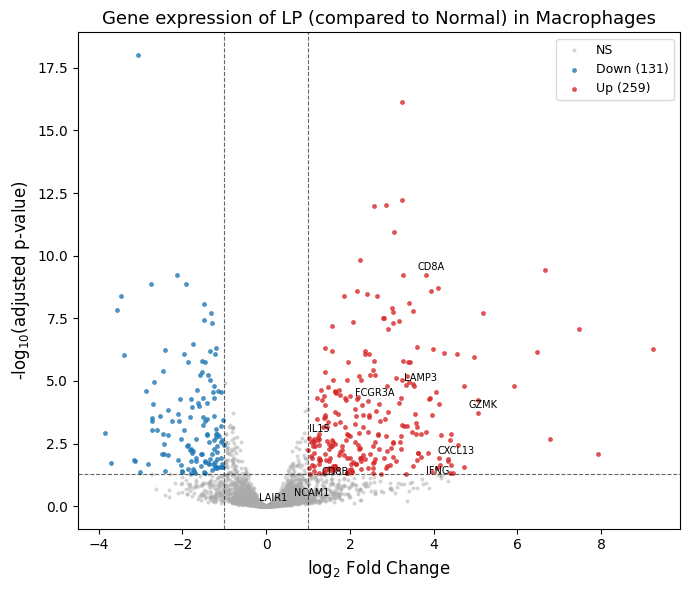

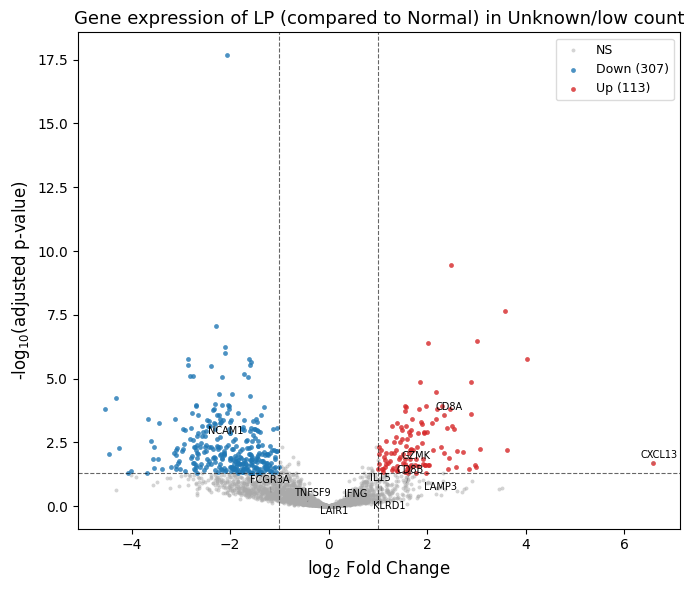

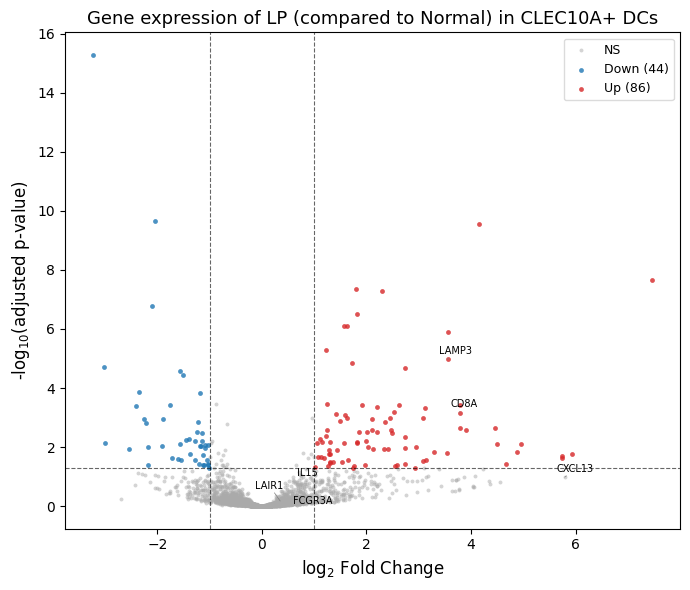

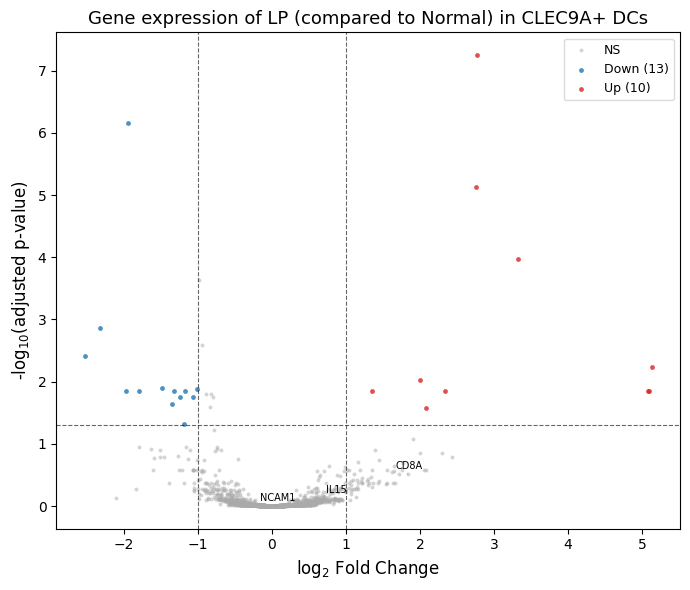

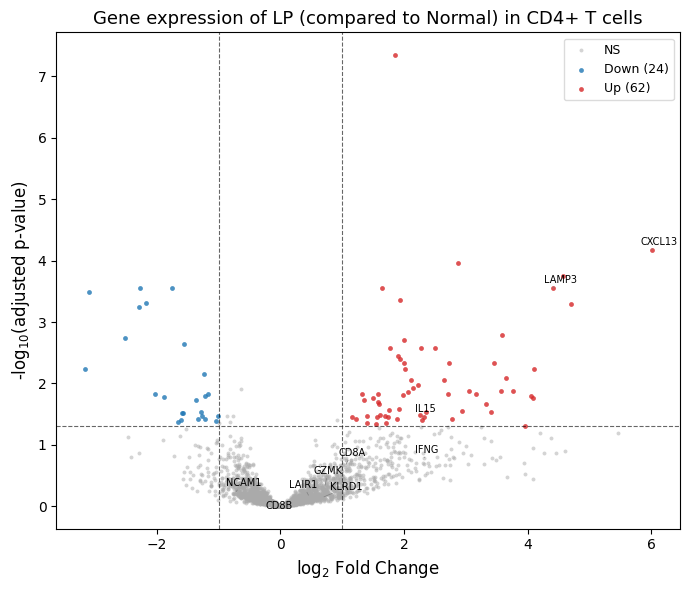

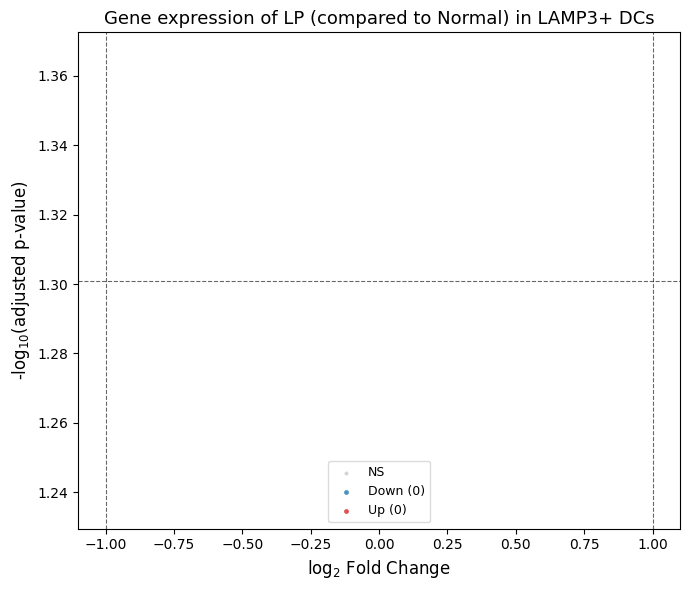

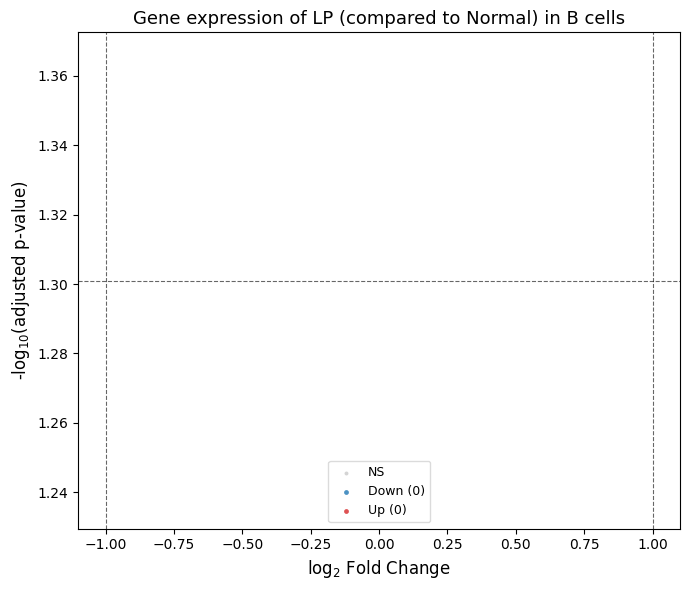

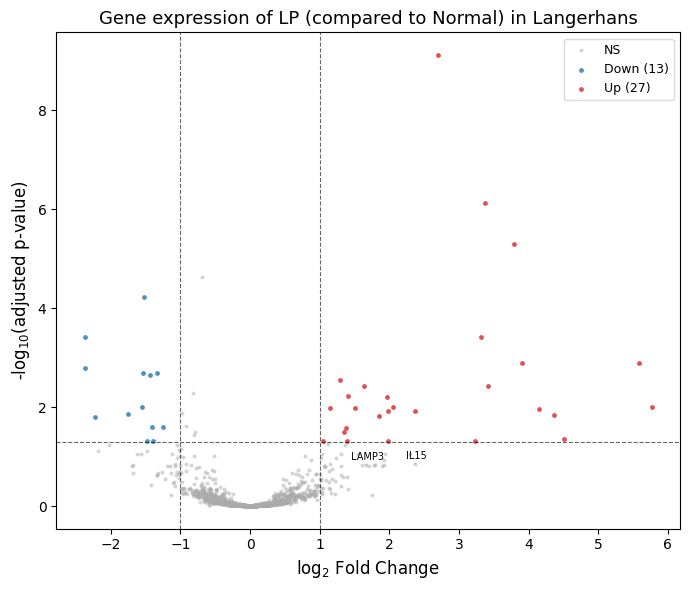

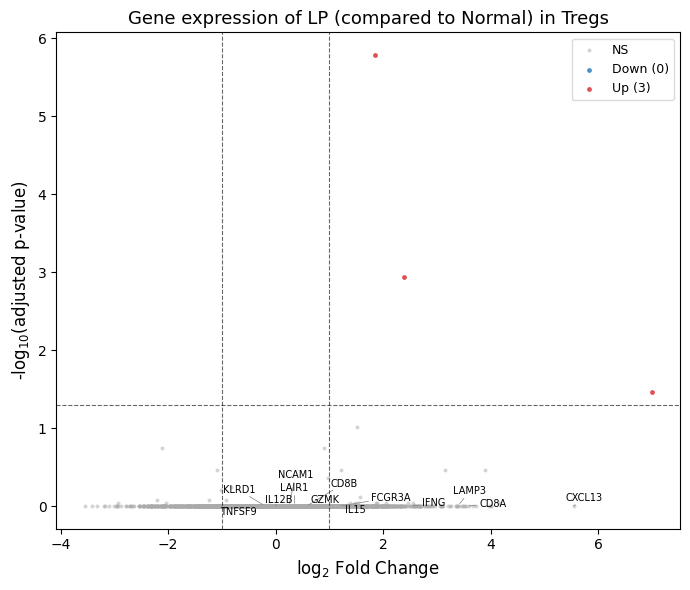

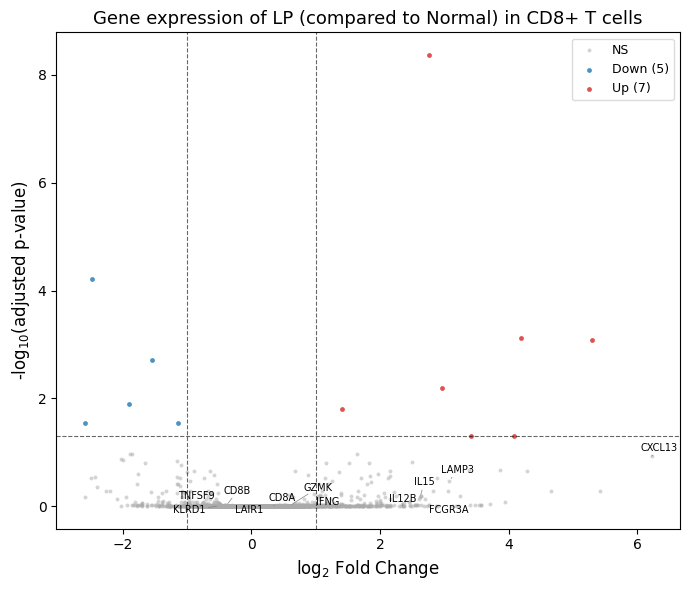

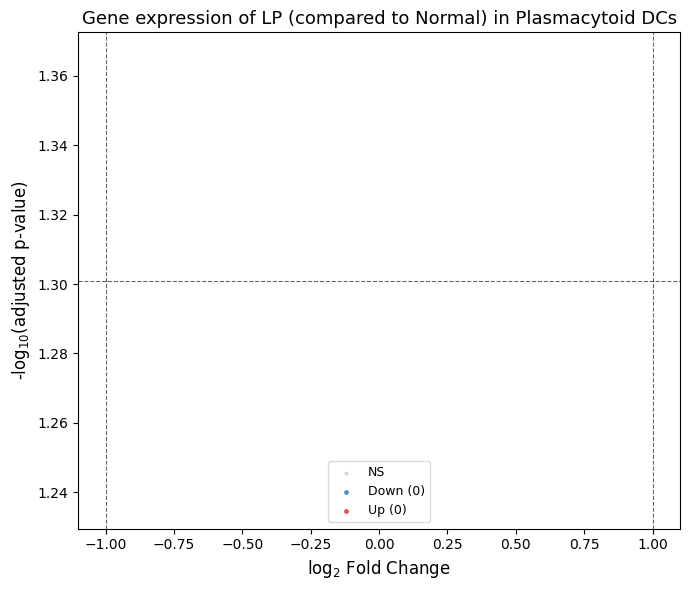

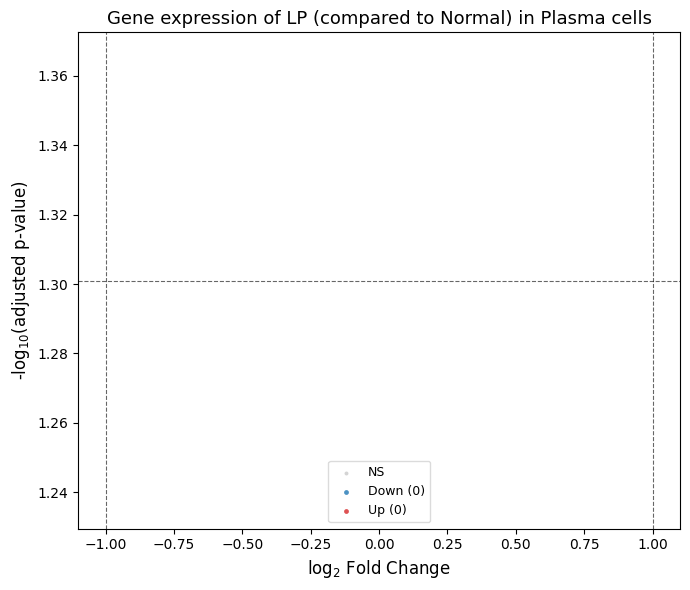

In [23]:
all_diffex_results_df = pd.read_csv('./output/lp-analysis/diffex/by_ct_diffex_results.csv')
all_diffex_results_df.ct.unique()


for ct in immune_cts:
    comparison = 'LP vs NL'

    df = all_diffex_results_df[(all_diffex_results_df['comparison'] == comparison) & (all_diffex_results_df['ct'] == ct)]
    plot_volcano(df, f'Gene expression of LP (compared to Normal) in {ct}', top_n_labels=0, labels=genes_of_interest)
    plt.show()

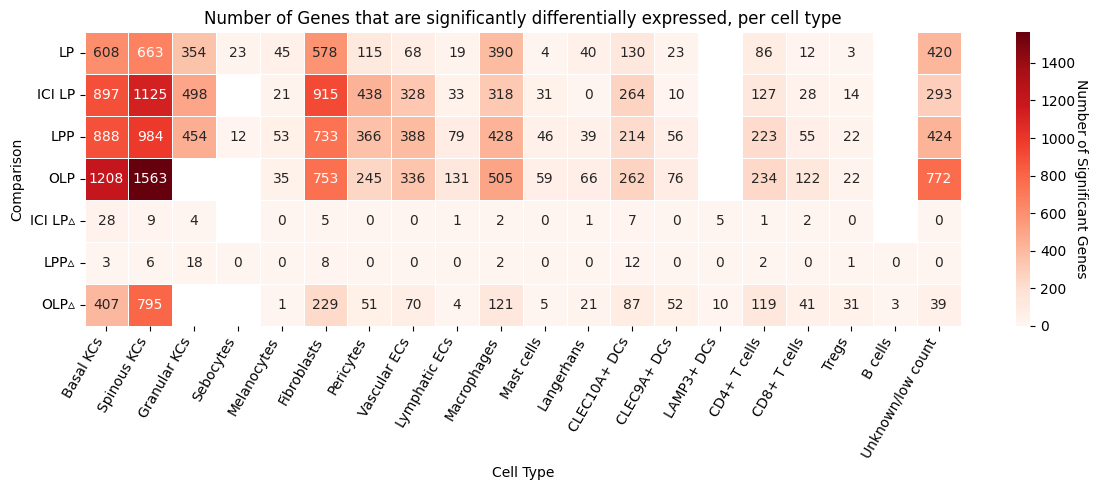

In [58]:
df_for_heatmap = pd.read_csv('./output/lp-analysis/diffex/by_ct_diffex_summary_by_ct.csv')
df_for_heatmap = df_for_heatmap.set_index('ct')

order =[
    'Basal KCs', 'Spinous KCs', 'Granular KCs', 'Sebocytes',
    'Melanocytes',
    'Fibroblasts', 'Pericytes',
    'Vascular ECs', 'Lymphatic ECs',
    'Macrophages', 'Mast cells', 'Langerhans', 'CLEC10A+ DCs', 'CLEC9A+ DCs', 'LAMP3+ DCs',
    'CD4+ T cells', 'CD8+ T cells', 'Tregs', 'B cells',
    'Unknown/low count',
]

df_for_heatmap = df_for_heatmap.loc[order]

comparison_map = {
    'LP vs NL':'LP',
    'ICI_LP vs NL':'ICI LP',
    'LPP vs NL':'LPP',
    'OLP vs NL':'OLP',
    'ICI_LP vs LP':'ICI LP▵',
    'LPP vs LP':'LPP▵',
    'OLP vs LP':'OLP▵',
}

col_order = comparison_map.values()#['LP', 'OLP', 'LPP', 'ICI LP', 'OLP▵', 'LPP▵', 'ICI LP▵']
df_for_heatmap.columns = df_for_heatmap.columns.map(comparison_map)
df_for_heatmap = df_for_heatmap[col_order].T

plt.figure(figsize=(12, 5))
sns.heatmap(df_for_heatmap, annot=True, fmt=".0f", cmap='Reds', linewidths=0.5) 
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.title('Number of Genes that are significantly differentially expressed, per cell type')
plt.ylabel('Comparison')
plt.xlabel('Cell Type')

cbar = plt.gca().collections[0].colorbar
cbar.set_label('Number of Significant Genes', rotation=270, ha='center', va='center')
plt.tight_layout()
plt.show()

# GSEA heatmap 

In [99]:
f_pattern = './output/lp-analysis/gsea_prerank_output/*/LP-NL/gseapy.gene_set.prerank.report.csv'
files = glob(f_pattern)

gsea_full_results = []
for f in files:
    df = pd.read_csv(f)
    
    ct = f.split('/')[-3]
    df.insert(0, 'ct', ct)
    
    gsea_full_results.append(df)

gsea_full_results_df = pd.concat(gsea_full_results, ignore_index=True)

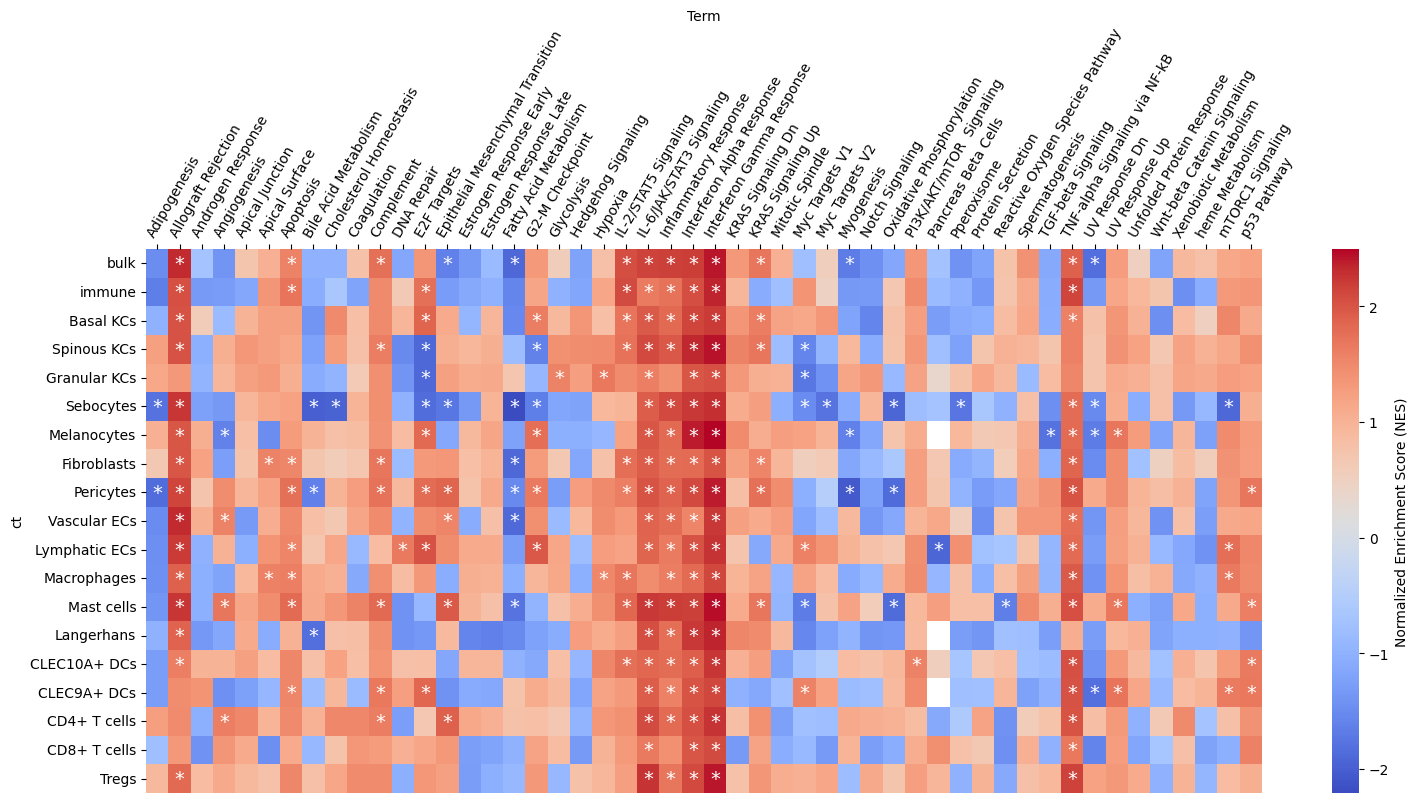

In [107]:
order = [
    'bulk',
    'immune',
    'Basal KCs', 'Spinous KCs', 'Granular KCs', 'Sebocytes',
    'Melanocytes',
    'Fibroblasts', 'Pericytes',
    'Vascular ECs', 'Lymphatic ECs',
    'Macrophages',  'Mast cells', 'Langerhans', 'CLEC10A+ DCs', 'CLEC9A+ DCs',
    'CD4+ T cells', 'CD8+ T cells', 'Tregs', 
]

plot_gsea_heatmap(gsea_full_results_df, 'ct', order=order, transpose=True, figsize=(8,18))